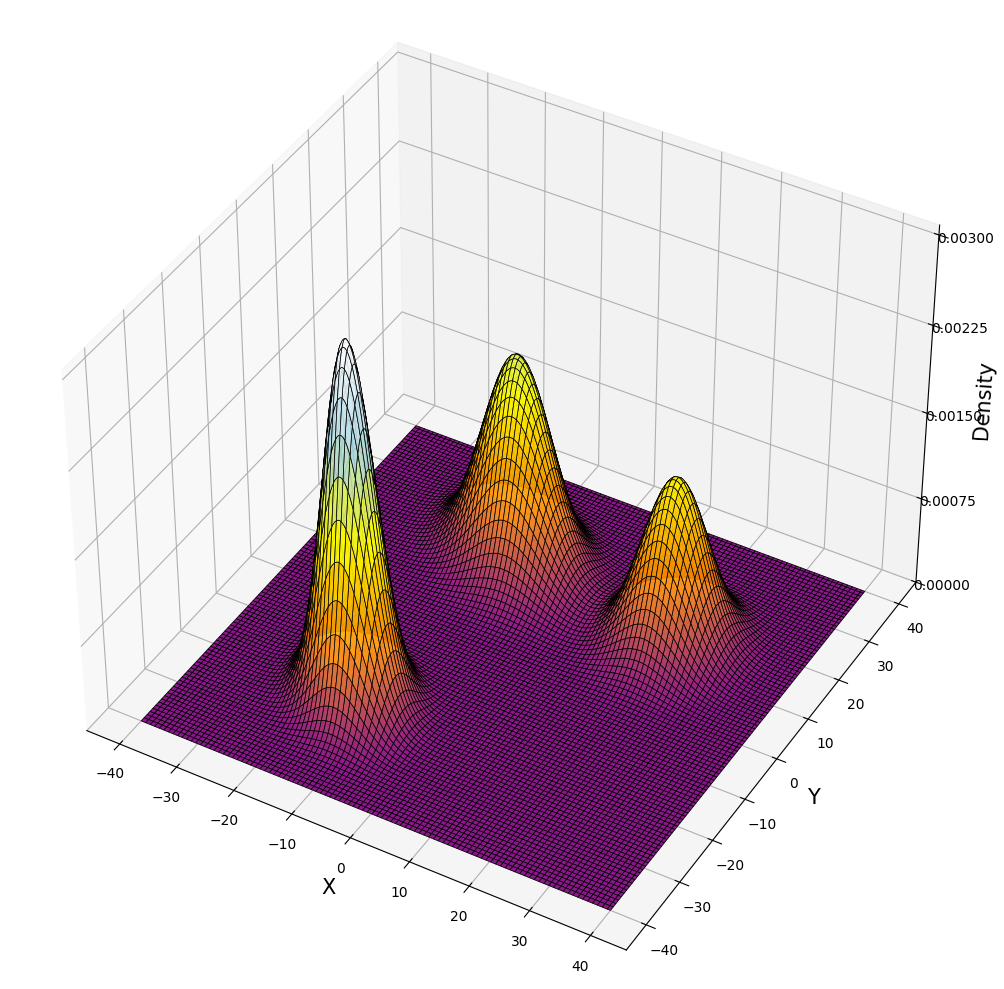

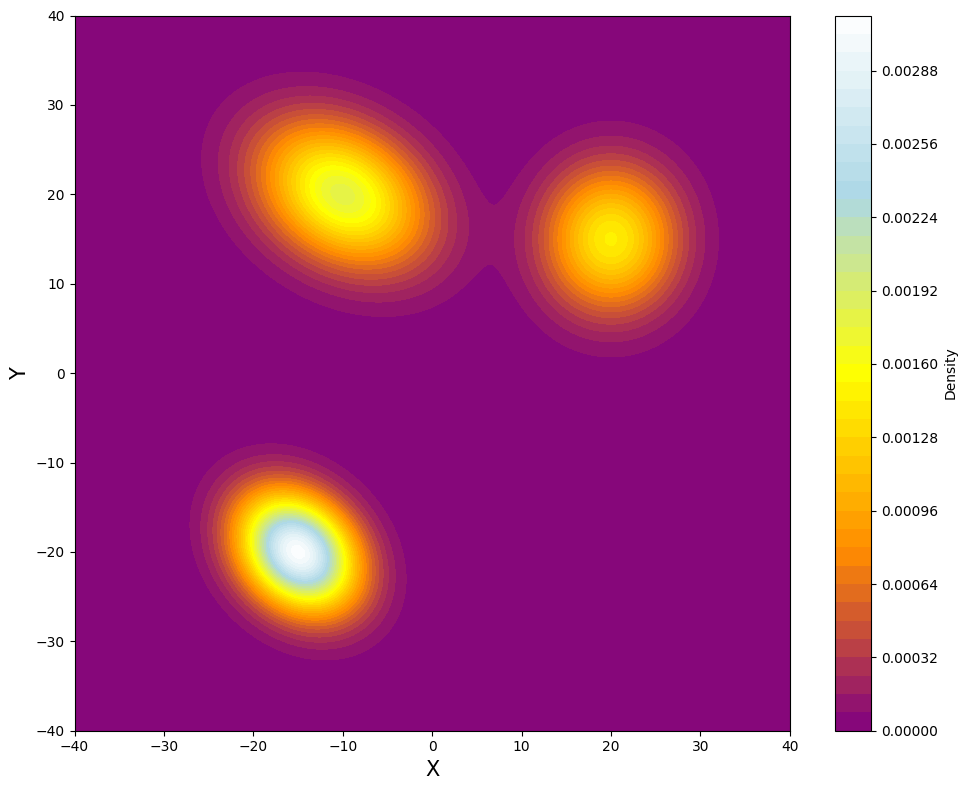

In [65]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.stats import multivariate_normal
from matplotlib.colors import LinearSegmentedColormap

# Generate a larger grid of x and y values
x = np.linspace(-40, 40, 300)
y = np.linspace(-40, 40, 300)
X, Y = np.meshgrid(x, y)

# Define anisotropic Gaussian distributions with increased blurring and new means
gaussian1 = multivariate_normal(mean=[-15, -20], cov=[[20, -5], [-5, 20]])  # Very blurred
gaussian2 = multivariate_normal(mean=[20, 15], cov=[[25, 0], [0, 30]])      # Very blurred
gaussian3 = multivariate_normal(mean=[-10, 20], cov=[[40, -10], [-10, 30]])   # Very blurred

# Define normalized weights for the Gaussians
weights = [1.5, 1.0, 1.5]
weights_sum = sum(weights)
normalized_weights = [w / weights_sum for w in weights]

# Combine the Gaussians using normalized weights
Z = (normalized_weights[0] * gaussian1.pdf(np.dstack((X, Y))) +
     normalized_weights[1] * gaussian2.pdf(np.dstack((X, Y))) +
     normalized_weights[2] * gaussian3.pdf(np.dstack((X, Y))))

# Create a colormap to resemble the desired color gradient
custom_colors = [
    "#800080",  # Purple
    "#FF8C00",  # Dark Orange
    "#FFFF00",  # Yellow
    "#ADD8E6",  # Light Blue
    "#FFFFFF"   # White
]
cmap = LinearSegmentedColormap.from_list("custom_cmap", custom_colors, N=256)

# -------------------------
# First Figure: 3D Surface Plot
# -------------------------
fig1 = plt.figure(figsize=(16, 10))  # Figure for the 3D surface plot
ax1 = fig1.add_subplot(111, projection='3d')

# Wireframe-style surface plot with thinner polygon lines
surface = ax1.plot_surface(X, Y, Z, cmap=cmap, edgecolor='k', linewidth=0.5, rstride=3, cstride=3, alpha=0.9)

# Adjust viewing angle
ax1.view_init(elev=40, azim=-60)

# Truncate the background grid visually at z = 0.003
z_ticks = np.linspace(0, 0.003, 5)  # Set ticks only up to 0.003
ax1.set_zticks(z_ticks)
ax1.set_zlim(0, Z.max())  # Keep the full height of the densities intact

# Label axes
ax1.set_xlabel('X', fontsize=15)
ax1.set_ylabel('Y', fontsize=15)
ax1.set_zlabel('Density', fontsize=15)

plt.tight_layout()
plt.show()

# -------------------------
# Second Figure: Contour Plot
# -------------------------
fig2, ax2 = plt.subplots(figsize=(10, 8))  # Figure for the contour plot
contour = ax2.contourf(X, Y, Z, levels=50, cmap=cmap)  # Contour plot with colors
ax2.set_xlabel('X', fontsize=15)
ax2.set_ylabel('Y', fontsize=15)
ax2.set_aspect('equal', 'box')  # Ensure the aspect ratio is equal
plt.colorbar(contour, ax=ax2, orientation='vertical', label='Density')

plt.tight_layout()
plt.show()

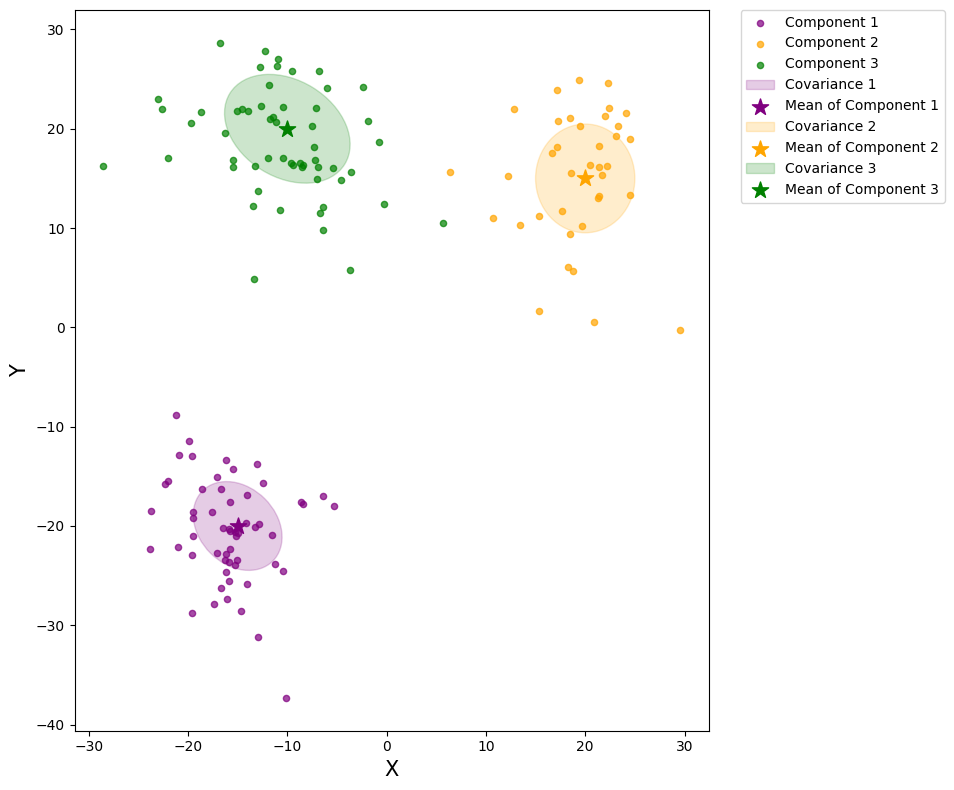

/var/folders/rs/z4yf99dx0wx_lqfdhc3l3dt40000gn/T/ipykernel_8546/4092772866.py:83: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend(loc='upper left', bbox_to_anchor=(1.05, 1), fontsize=10, borderaxespad=0)


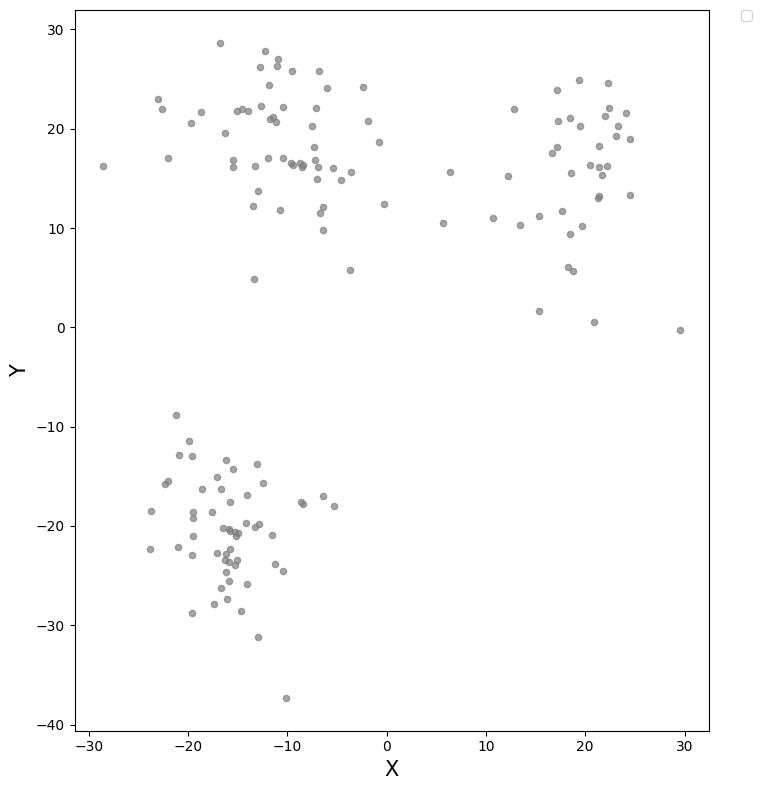

In [76]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal
from matplotlib.patches import Ellipse

# Define means and covariances of the Gaussian components
means = np.array([[-15, -20], [20, 15], [-10, 20]])
covariances = [
    np.array([[20, -5], [-5, 20]]),
    np.array([[25, 0], [0, 30]]),
    np.array([[40, -10], [-10, 30]])
]

# Define weights of the Gaussian components
weights = np.array([1.5, 1.0, 1.5])
weights /= np.sum(weights)  # Normalize weights

# Reduced number of samples
num_samples = 150

# Sample from the mixture distribution
samples = []
labels = []
for i, (mean, cov, weight) in enumerate(zip(means, covariances, weights)):
    num = int(num_samples * weight)  # Allocate samples proportionally
    samples_i = np.random.multivariate_normal(mean, cov, num)
    samples.append(samples_i)
    labels.extend([i] * num)

samples = np.vstack(samples)
labels = np.array(labels)

# Define custom color palette
colors = ['#800080', '#FFA500', '#008000']  # Purple, Orange, Green from your palette

# -------------------------
# First Plot: Full plot with ellipses and mean points
# -------------------------
fig1, ax1 = plt.subplots(figsize=(10, 8))

# Plot samples colored by component
for i, color in enumerate(colors):
    component_samples = samples[labels == i]
    ax1.scatter(component_samples[:, 0], component_samples[:, 1], s=20, color=color, label=f'Component {i + 1}', alpha=0.7)

# Add covariance ellipses and mean points
for i, (mean, cov, color) in enumerate(zip(means, covariances, colors)):
    # Compute the eigenvalues and eigenvectors of the covariance matrix
    eigvals, eigvecs = np.linalg.eigh(cov)
    angle = np.degrees(np.arctan2(*eigvecs[:, 0][::-1]))
    width, height = 2 * np.sqrt(eigvals)  # 2 standard deviations
    ellipse = Ellipse(xy=mean, width=width, height=height, angle=angle, edgecolor=color, facecolor=color, alpha=0.2, label=f'Covariance {i + 1}')
    ax1.add_patch(ellipse)
    
    # Plot the mean as a star mark
    ax1.scatter(mean[0], mean[1], color=color, s=150, marker='*', label=f'Mean of Component {i + 1}')

# Add labels, legend, and equal aspect ratio
ax1.set_xlabel('X', fontsize=15)
ax1.set_ylabel('Y', fontsize=15)
ax1.set_aspect('equal', 'box')

# Draw the legend outside the figure
ax1.legend(loc='upper left', bbox_to_anchor=(1.05, 1), fontsize=10, borderaxespad=0)

plt.tight_layout()
plt.show()

# -------------------------
# Second Plot: Only the sampled points without colors
# -------------------------
fig2, ax2 = plt.subplots(figsize=(10, 8))

# Plot all sampled points in a neutral color (gray)
ax2.scatter(samples[:, 0], samples[:, 1], s=20, color='gray', alpha=0.7)

# Add labels and equal aspect ratio
ax2.set_xlabel('X', fontsize=15)
ax2.set_ylabel('Y', fontsize=15)
ax2.set_aspect('equal', 'box')

# Draw the legend outside the figure
ax2.legend(loc='upper left', bbox_to_anchor=(1.05, 1), fontsize=10, borderaxespad=0)

plt.tight_layout()
plt.show()